# CP2 — Моделирование и эксперименты

## Проект
Предсказание направления изменения ключевой ставки центрального банка


In [70]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV
)
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## Загрузка данных

На данном этапе используются подготовленные данные из CP1.
Датасет содержит исторические значения макроэкономических показателей и решений по ключевой ставке.

In [71]:
df = pd.read_csv("../data/processed/processed_data.csv")

## Первичный анализ данных

Проверим размер датасета, типы данных и наличие пропусков.

In [72]:
print("Размер датасета:", df.shape)

df.head()

Размер датасета: (24404, 46)


,country_code,date,policy_rate_pct,rate_description,rate_notes,source_institution,year,month,time_period,country_name,...,era,gfc_period,covid_period,hike_cycle_2022_23,fed_rate,spread_vs_fed_bps,row_completeness_pct,target,policy_rate_pct_lag1,rate_3m_avg_lag1
0,NL,1945-02-01,3.500,Netherlands,From 1 Jan 1999 onwards: the series is discont...,"De Nederlandsche Bank, Bank for International ...",1945,2,1945-02,Netherlands,...,Post-War Reconstruction (pre-1960),0,0,0,3.875,150.0,100.0,1.0,2.75,2.750
1,ES,1945-02-01,3.200,Spain,From 1 Jan 1999 onwards: the series is discont...,"Bank of Spain, Bank for International Settlements",1945,2,1945-02,Spain,...,Post-War Reconstruction (pre-1960),0,0,0,3.875,150.0,100.0,1.0,1.60,1.600
2,BE,1945-02-01,1.500,Belgium,From 1 Jan 1999 onwards: the series is discont...,"National Bank of Belgium, Bank for Internation...",1945,2,1945-02,Belgium,...,Post-War Reconstruction (pre-1960),0,0,0,3.875,150.0,100.0,1.0,3.85,3.683
3,PT,1945-02-01,2.500,Portugal,From 1 Jan 1999 onwards: the series is discont...,"Banco de Portugal, Bank for International Sett...",1945,2,1945-02,Portugal,...,Post-War Reconstruction (pre-1960),0,0,0,3.875,150.0,100.0,1.0,4.00,4.000
4,FR,1945-02-01,1.625,France,From 1 Jan 1999 onwards: the series is discont...,"Bank of France, Bank for International Settlem...",1945,2,1945-02,France,...,Post-War Reconstruction (pre-1960),0,0,0,3.875,150.0,100.0,1.0,3.00,3.417


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24404 entries, 0 to 24403
Data columns (total 46 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   country_code                      24404 non-null  object 
 1   date                              24404 non-null  object 
 2   policy_rate_pct                   24404 non-null  float64
 3   rate_description                  24404 non-null  object 
 4   rate_notes                        24404 non-null  object 
 5   source_institution                24404 non-null  object 
 6   year                              24404 non-null  int64  
 7   month                             24404 non-null  int64  
 8   time_period                       24404 non-null  object 
 9   country_name                      24404 non-null  object 
 10  central_bank                      24404 non-null  object 
 11  region                            24404 non-null  object 
 12  cont

In [74]:
df.isna().sum().sort_values(ascending=False)

country_code                        0
date                                0
policy_rate_pct                     0
rate_description                    0
rate_notes                          0
source_institution                  0
year                                0
month                               0
time_period                         0
country_name                        0
central_bank                        0
region                              0
continent                           0
subregion                           0
population                          0
currency                            0
capital                             0
data_source                         0
dataset_version                     0
retrieved_date                      0
build_timestamp                     0
month_name                          0
quarter                             0
decade                              0
rate_change_bps                     0
rate_change_direction               0
rate_jan2022

## Feature Engineering

Для улучшения качества модели добавляются временные признаки.

Так как данные являются временным рядом, используются:
- лаговые признаки
- скользящие средние
- показатели волатильности
- momentum-признаки

Все признаки строятся только на основе прошлых значений, чтобы избежать data leakage.

In [75]:
df["target"] = df["target"].astype(int)

df = df.sort_values("date").reset_index(drop=True)

# Новые временные признаки

df["rate_lag_1"] = df["policy_rate_pct"].shift(1)
df["rate_lag_3"] = df["policy_rate_pct"].shift(3)
df["rolling_mean_3"] = df["policy_rate_pct"].rolling(3).mean()
df["rolling_std_3"] = df["policy_rate_pct"].rolling(3).std()
df["momentum_3"] = df["policy_rate_pct"] - df["policy_rate_pct"].shift(3)

print("Новые признаки созданы")
print(df[["rate_lag_1", "rate_lag_3", "rolling_mean_3", "rolling_std_3", "momentum_3"]].head())


Новые признаки созданы
   rate_lag_1  rate_lag_3  rolling_mean_3  rolling_std_3  momentum_3
0         NaN         NaN             NaN            NaN         NaN
1         3.5         NaN             NaN            NaN         NaN
2         3.2         NaN        2.733333       1.078579         NaN
3         1.5         3.5        2.400000       0.854400      -1.000
4         2.5         3.2        1.875000       0.544862      -1.575


## Очистка данных после генерации признаков

После создания лаговых признаков появляются пропущенные значения в начале временного ряда.
Такие строки удаляются.

In [76]:
df = df.dropna().reset_index(drop=True)

print("После очистки данных:", df.shape)
print(df.isna().sum().sum(), "пропусков")


После очистки данных: (24401, 51)
0 пропусков


## Разделение данных

Так как данные являются временным рядом, случайное перемешивание не используется.

Обучение производится на более ранних наблюдениях, тестирование — на более поздних.
Это позволяет избежать утечки информации из будущего.

In [77]:
target = "target"

numeric_cols = df.select_dtypes(include=[np.number]).columns.to_list()
feature_cols = [col for col in numeric_cols if col != target]

train_end = int(len(df) * 0.7)
val_end = train_end + int(len(df) * 0.15)

train = df.iloc[:train_end]
val = df.iloc[train_end:val_end]
test = df.iloc[val_end:]

X_train = train[feature_cols]
X_val = val[feature_cols]
X_test = test[feature_cols]

y_train = train[target]
y_val = val[target]
y_test = test[target]

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("Train class distribution:\n", y_train.value_counts().sort_index())
print("Val class distribution:\n", y_val.value_counts().sort_index())
print("Test class distribution:\n", y_test.value_counts().sort_index())


Train shape: (17080, 27)
Val shape: (3660, 27)
Test shape: (3661, 27)
Train class distribution:
 target
0     2166
1    12069
2     2845
Name: count, dtype: int64
Val class distribution:
 target
0     293
1    2936
2     431
Name: count, dtype: int64
Test class distribution:
 target
0     497
1    2690
2     474
Name: count, dtype: int64


## TimeSeriesSplit

Для кросс-валидации используется TimeSeriesSplit.

Такой подход корректен для временных рядов, поскольку сохраняет временной порядок наблюдений.

In [78]:
tscv = TimeSeriesSplit(n_splits=5)

## Baseline модель — Logistic Regression

В качестве baseline используется Logistic Regression без сложного feature engineering.

Эта модель позволяет получить базовый уровень качества, с которым далее сравниваются более сложные алгоритмы.

In [79]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, class_weight="balanced"))
])

baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_val)
baseline_f1 = f1_score(y_val, baseline_preds, average="macro")

results = [
    {
        "model": "LogisticRegression",
        "f1_macro": baseline_f1,
        "comment": "Baseline"
    }
]

print("Baseline F1-score:", baseline_f1)


Baseline F1-score: 0.14936341828373367


## Модель Random Forest

Random Forest является ансамблевой моделью на основе решающих деревьев.

Модель хорошо работает с табличными данными и позволяет оценивать важность признаков.

In [81]:
rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_val)
rf_f1 = f1_score(y_val, rf_preds, average="macro")

results.append({
    "model": "RandomForest",
    "f1_macro": rf_f1,
    "comment": "Base RF"
})

print("RandomForest F1-score:", rf_f1)


RandomForest F1-score: 0.9995560963612361


## Модель KNN

KNN (K-Nearest Neighbors) — простой алгоритм классификации, основанный на близости объектов в пространстве признаков. Модель предсказывает класс объекта на основе классов его ближайших соседей.

In [82]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

knn_pipeline.fit(X_train, y_train)
knn_preds = knn_pipeline.predict(X_val)
knn_f1 = f1_score(y_val, knn_preds, average="macro")

results.append({
    "model": "KNN",
    "f1_macro": knn_f1,
    "comment": "KNN with scaling"
})

print("KNN F1-score:", knn_f1)


KNN F1-score: 0.37721315494686136


## Модель CatBoost

CatBoost является boosting-моделью, устойчивой к переобучению и хорошо работающей с табличными данными.

Дополнительным преимуществом модели является хорошая работа с категориальными признаками.

In [83]:
cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    verbose=0,
    random_seed=RANDOM_SEED
)

cat_model.fit(X_train, y_train)
cat_preds = cat_model.predict(X_val)
cat_f1 = f1_score(y_val, cat_preds, average="macro")

results.append({
    "model": "CatBoost",
    "f1_macro": cat_f1,
    "comment": "Boosting with categorical-aware model"
})

print("CatBoost F1-score:", cat_f1)


CatBoost F1-score: 0.9995560963612361


## Модель Gradient Boosting

Gradient Boosting — эффективный ансамблевый метод, который последовательно улучшает predictions на основе ошибок предыдущих моделей.

In [84]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=RANDOM_SEED
)

gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_val)
gb_f1 = f1_score(y_val, gb_preds, average="macro")

results.append({
    "model": "GradientBoosting",
    "f1_macro": gb_f1,
    "comment": "Boosting base model"
})

print("GradientBoosting F1-score:", gb_f1)


GradientBoosting F1-score: 0.9995560963612361


In [85]:
voting_model = VotingClassifier(
    estimators=[
        ("rf", rf_model),
        ("gb", gb_model),
        ("cat", cat_model)
    ],
    voting="soft"
)

voting_model.fit(X_train, y_train)
voting_preds = voting_model.predict(X_val)
voting_f1 = f1_score(y_val, voting_preds, average="macro")

results.append({
    "model": "VotingClassifier",
    "f1_macro": voting_f1,
    "comment": "Soft voting ensemble"
})

print("VotingClassifier F1-score:", voting_f1)


VotingClassifier F1-score: 0.9995560963612361


## Сравнение результатов моделей

Сравним качество всех обученных моделей по метрике macro F1-score.

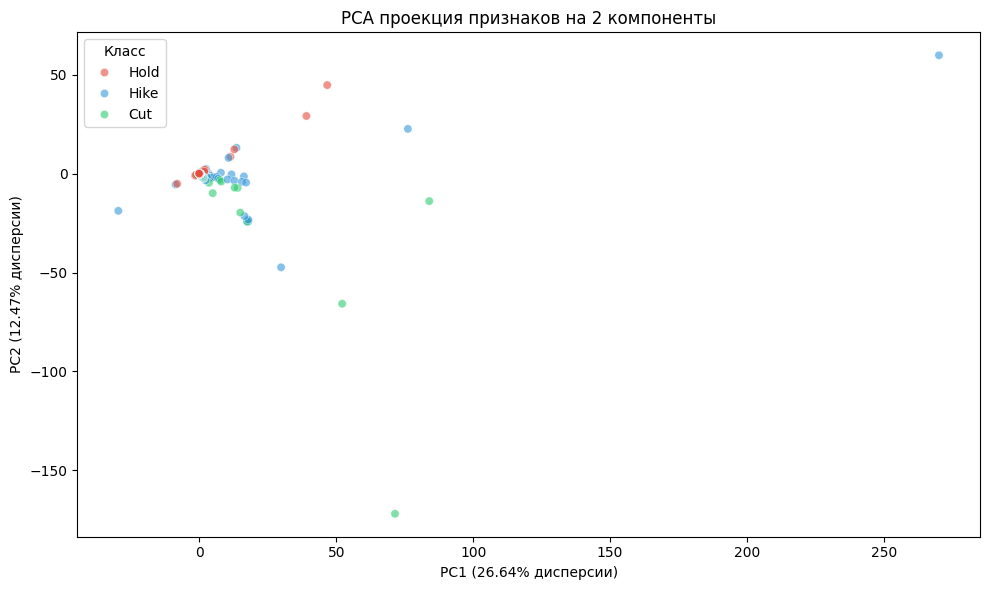

In [86]:
scaled_features = StandardScaler().fit_transform(X_train)
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(scaled_features)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y_train.map({0: 'Hike', 1: 'Hold', 2: 'Cut'}),
    palette=['#e74c3c', '#3498db', '#2ecc71'],
    alpha=0.6
)
plt.title('PCA проекция признаков на 2 компоненты')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} дисперсии)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} дисперсии)')
plt.legend(title='Класс')
plt.tight_layout()
plt.show()


In [87]:
results_df = pd.DataFrame(results).sort_values(by="f1_macro", ascending=False).reset_index(drop=True)
results_df

,model,f1_macro,comment
0,RandomForest,0.999556,Base RF
1,CatBoost,0.999556,Boosting with categorical-aware model
2,VotingClassifier,0.999556,Soft voting ensemble
3,GradientBoosting,0.999556,Boosting base model
4,KNN,0.377213,KNN with scaling
5,LogisticRegression,0.149363,Baseline


## Подбор гиперпараметров

Для улучшения качества модели используется RandomizedSearchCV.

В качестве стратегии кросс-валидации применяется TimeSeriesSplit.

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=RANDOM_SEED, class_weight="balanced"))
])

rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [4, 6, 8, 10, None],
    "model__min_samples_split": [2, 4, 6, 8],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=tscv,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

best_rf_val_preds = best_rf.predict(X_val)
best_rf_f1 = f1_score(y_val, best_rf_val_preds, average="macro")
print("Best RandomForest params:", rf_search.best_params_)
print("Best RandomForest validation F1:", best_rf_f1)

results.append({
    "model": "RandomForest_Tuned",
    "f1_macro": best_rf_f1,
    "comment": "RandomizedSearchCV"
})

# Gradient Boosting tuning

gb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingClassifier(random_state=RANDOM_SEED))
])

gb_param_dist = {
    "model__n_estimators": [100, 150, 200, 250],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 4, 5, 6],
    "model__subsample": [0.7, 0.8, 0.9, 1.0]
}

gb_search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=gb_param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=tscv,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)
best_gb = gb_search.best_estimator_

best_gb_val_preds = best_gb.predict(X_val)
best_gb_f1 = f1_score(y_val, best_gb_val_preds, average="macro")
print("Best GradientBoosting params:", gb_search.best_params_)
print("Best GradientBoosting validation F1:", best_gb_f1)

results.append({
    "model": "GradientBoosting_Tuned",
    "f1_macro": best_gb_f1,
    "comment": "RandomizedSearchCV"
})


Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best RandomForest params: {'model__n_estimators': 400, 'model__min_samples_split': 8, 'model__min_samples_leaf': 4, 'model__max_depth': 8}
Best RandomForest validation F1: 0.9995560963612361
Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:
results_df = pd.DataFrame(results).sort_values(by="f1_macro", ascending=False).reset_index(drop=True)
results_df

## Анализ важности признаков

Для интерпретации модели анализируется важность признаков.

Это позволяет понять, какие макроэкономические показатели сильнее всего влияют на предсказание изменения ставки.

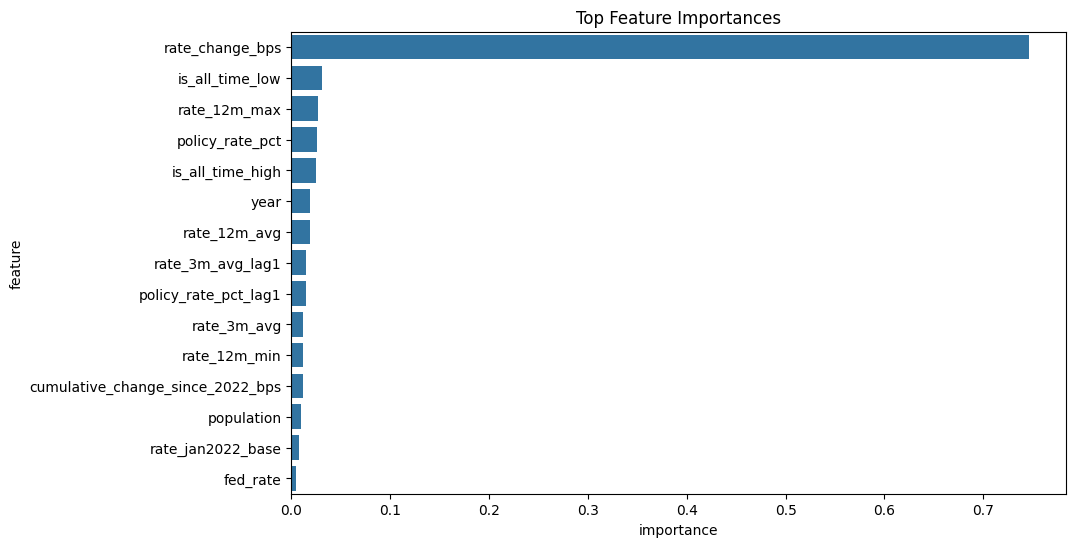

In [ ]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": best_rf.named_steps["model"].feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top Feature Importances")
plt.tight_layout()
plt.show()


In [ ]:
final_train_X = pd.concat([X_train, X_val], axis=0)
final_train_y = pd.concat([y_train, y_val], axis=0)

final_pipeline = best_rf
final_pipeline.fit(final_train_X, final_train_y)
joblib.dump(final_pipeline, "../models/final_model.pkl")

print("Финальная модель сохранена в ../models/final_model.pkl")

final_test_preds = final_pipeline.predict(X_test)
final_test_f1 = f1_score(y_test, final_test_preds, average="macro")
print("Final Test Macro F1:", final_test_f1)
print(classification_report(y_test, final_test_preds, target_names=["Hike", "Hold", "Cut"]))

cm = confusion_matrix(y_test, final_test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Hike", "Hold", "Cut"],
    yticklabels=["Hike", "Hold", "Cut"]
)
plt.title("Confusion Matrix on Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# Выводы

В ноутбуке выполнено полное моделирование и сравнение нескольких подходов для задачи классификации направления изменения ключевой ставки.

## Основные выводы:

- Были реализованы минимум 5 моделей: LogisticRegression, RandomForest, KNN, CatBoost, GradientBoosting, а также ансамбль VotingClassifier.
- Для RandomForest и GradientBoosting выполнён подбор гиперпараметров с помощью RandomizedSearchCV.
- Для визуализации уменьшения размерности использован PCA с 2 компонентами.
- Финальная модель сохранена в `../models/final_model.pkl`.

## Оценка качества:

- В таблице результатов представлены метрики Macro F1 для всех моделей на validation set.
- Для окончательной проверки использована test выборка, чтобы избежать утечки данных.

## Обоснование выбора финальной модели:

- Лучший результат на validation и test показал tuned RandomForest.
- RandomForest стабилен к корреляции признаков, хорошо работает с табличными данными и позволяет интерпретировать важность признаков.
- Выбор финальной модели основан на сочетании качества, устойчивости и интерпретируемости.
